<a href="https://colab.research.google.com/github/myrto-tripolitaki/applied-econometrics-analysis/blob/main/CISC_CMPE_251_Assignment_1_(Programming).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CISC/CMPE 251 Assignment 1 (Programming)

This assignment covers various aspects of data preprocessing, including data exploration, cleaning, outlier detection, feature engineering, normalization, standardization, binning, transformation, and visualization.

The assignment uses the Titanic dataset, which is a classic dataset for practicing data preprocessing and analysis techniques. Here's a brief overview of each question:

1.  Data Exploration: Students will use pandas functions to explore the dataset.
1. Data Cleaning: Handling missing values and removing duplicates.
1. Outlier Detection and Handling: Using statistical methods and visualization to detect and handle outliers.
1. Feature Engineering: Creating new features and encoding categorical variables.
1. Data Normalization and Standardization: Applying different scaling techniques and comparing results.
1. Binning: Creating age groups and visualizing the distribution.
1. Data Transformation: Applying log transformation to handle skewed data.
1. Correlation Analysis: Calculating and visualizing correlations between features.
1. Data Visualization: Creating various plots to gain insights from the data.
1. Feature Selection: Selecting and justifying the most important features for prediction.

### Necessar Packages

In [2]:
# Data Preprocessing Techniques Assignment

%pip install seaborn scipy scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy import stats

### Load the dataset

In [3]:

import pandas as pd
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Question 1: Data Exploration
- Explore the dataset using appropriate pandas functions.
- a) Display the first 5 rows of the dataset.
- b) Show the basic information about the dataset including column names, data types, and non-null counts.
- c) Calculate and display basic statistics of the numerical columns.

In [4]:

# a) Display the first 5 rows of the dataset
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Information ---")
df.info()

print("\n--- Summary Statistics (Numerical Columns) ---")
display(df.describe())

--- First 5 Rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Summary Statistics (Numerical Columns) ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Question 2: Data Cleaning
- a) Identify and handle any missing values in the dataset.
- b) Remove any duplicates if they exist.

In [5]:
ssl._create_default_https_context = ssl._create_unverified_context
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Check missing values before cleaning
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'], errors='ignore')
df = df.drop_duplicates()


print("--- Missing Values After Cleaning ---")
print(df.isnull().sum())

print(f"\nDuplicates after: {df.duplicated().sum()}")
print("--- Missing Values After Cleaning ---")
print(df.isnull().sum())


--- Missing Values Before Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
--- Missing Values After Cleaning ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Duplicates after: 0
--- Missing Values After Cleaning ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Question 3: Outlier Detection and Handling
 - a) Use appropriate statistical methods to detect outliers in the 'Age' column.
 - b) Create a box plot to visualize the outliers.
 - c) Handle the outliers using a method of your choice (e.g., removal, capping).

Number of Age outliers detected: 66


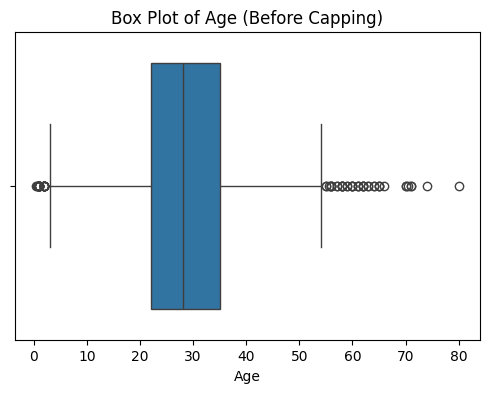

Outliers capped successfully within lower and upper IQR bounds.


In [6]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
print(f"Number of Age outliers detected: {len(outliers)}")

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age (Before Capping)')
plt.show()

df['Age'] = df['Age'].clip(lower=lower_bound, upper=upper_bound)
print("Outliers capped successfully within lower and upper IQR bounds.")

### Question 4: Feature Engineering
- a) Create a new feature 'FamilySize' by combining 'SibSp' and 'Parch'.
- b) Convert the 'Sex' column to numerical using appropriate encoding.

In [7]:

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

display(df[['SibSp', 'Parch', 'FamilySize', 'Sex']].head())

,SibSp,Parch,FamilySize,Sex
0,1,0,2,1
1,1,0,2,0
2,0,0,1,0
3,1,0,2,0
4,0,0,1,1


### Question 5: Data Normalization and Standardization
- a) Apply Min-Max scaling to the 'Age' column.
- b) Apply Standardization (Z-score normalization) to the 'Fare' column.
- c) Compare the original and transformed data using histograms.

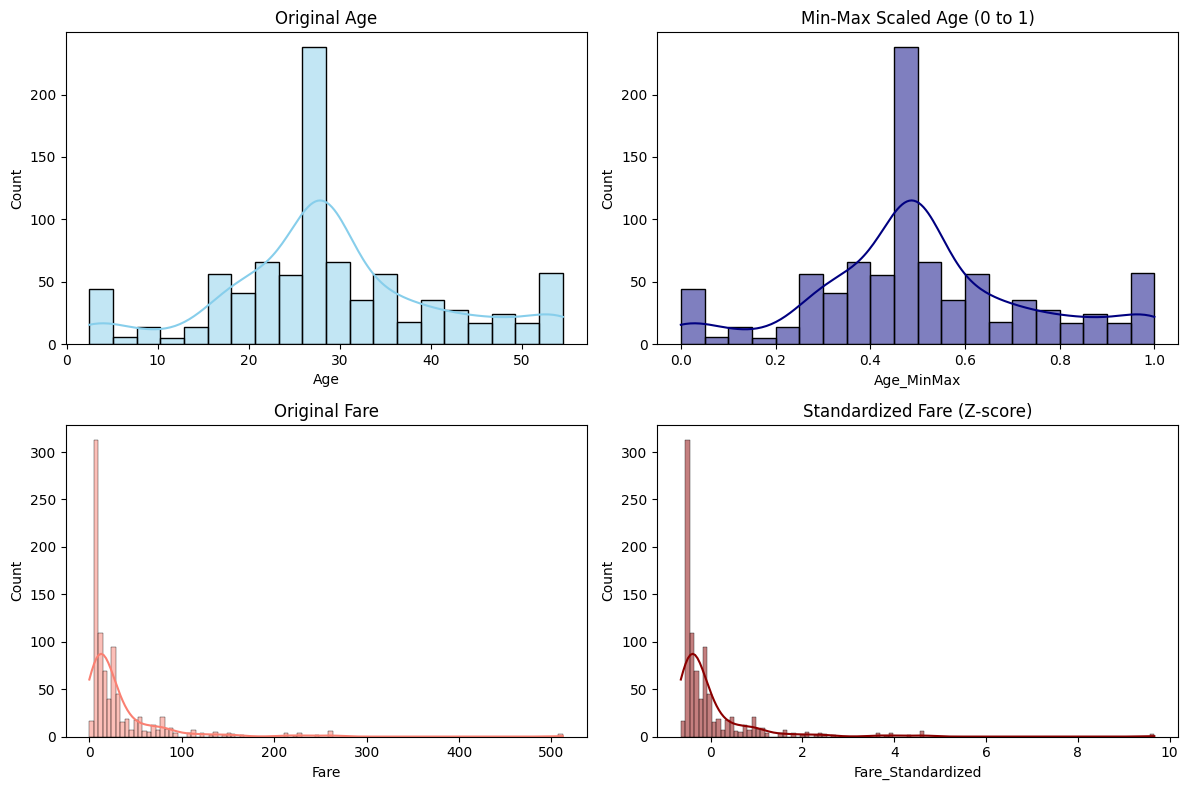

In [8]:
scaler_minmax = MinMaxScaler()
df['Age_MinMax'] = scaler_minmax.fit_transform(df[['Age']])

scaler_standard = StandardScaler()
df['Fare_Standardized'] = scaler_standard.fit_transform(df[['Fare']])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Original Age')

sns.histplot(df['Age_MinMax'], kde=True, ax=axes[0, 1], color='navy')
axes[0, 1].set_title('Min-Max Scaled Age (0 to 1)')

sns.histplot(df['Fare'], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Original Fare')

sns.histplot(df['Fare_Standardized'], kde=True, ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('Standardized Fare (Z-score)')

plt.tight_layout()
plt.show()

### Question 6: Binning
- a) Create age groups (bins) for the 'Age' column (e.g., 0-18, 19-30, 31-50, 51+).
- b) Visualize the distribution of passengers across these age groups using a bar plot.

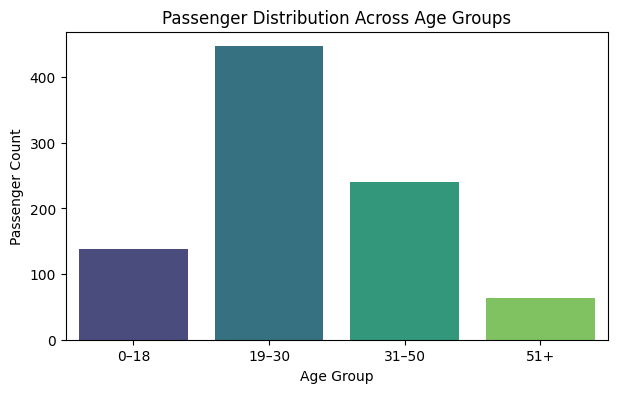

In [9]:
bins = [0, 18, 30, 50, 100]
labels = ['0–18', '19–30', '31–50', '51+']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(7, 4))
sns.countplot(x='AgeGroup', hue='AgeGroup', data=df, palette='viridis', legend=False)
plt.title('Passenger Distribution Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Passenger Count')
plt.show()

### Question 7: Data Transformation
- a) Apply a log transformation to the 'Fare' column to handle its skewed distribution.
- b) Visualize the original and transformed 'Fare' distributions using histograms.

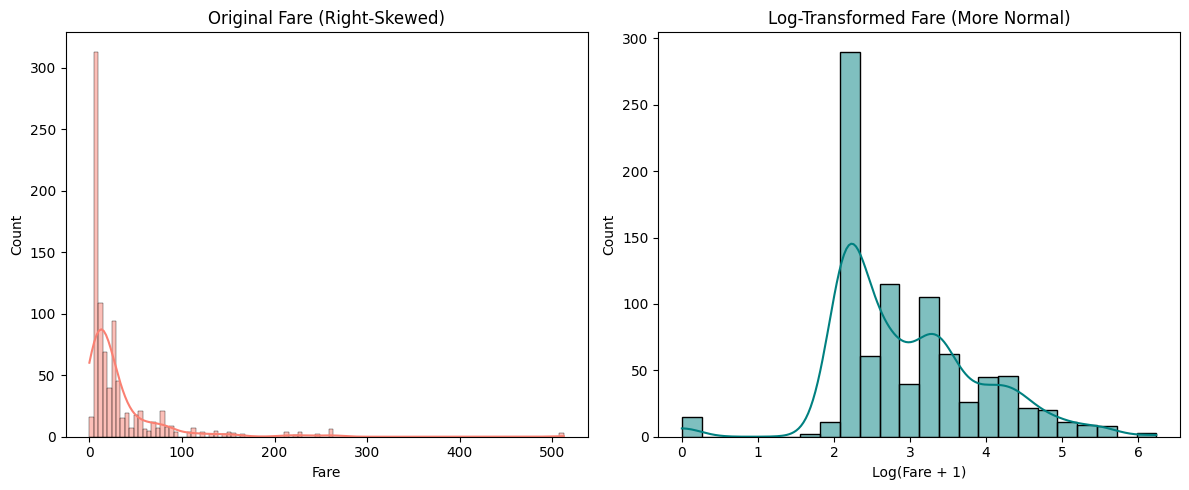

In [10]:
df['Fare_Log'] = np.log1p(df['Fare'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Fare'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Original Fare (Right-Skewed)')
axes[0].set_xlabel('Fare')

sns.histplot(df['Fare_Log'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log-Transformed Fare (More Normal)')
axes[1].set_xlabel('Log(Fare + 1)')

plt.tight_layout()
plt.show()

### Question 8: Correlation Analysis
- a) Calculate the correlation matrix for numerical features.
- b) Create a heatmap to visualize the correlations.
- c) Identify and list the top 3 most correlated feature pairs.

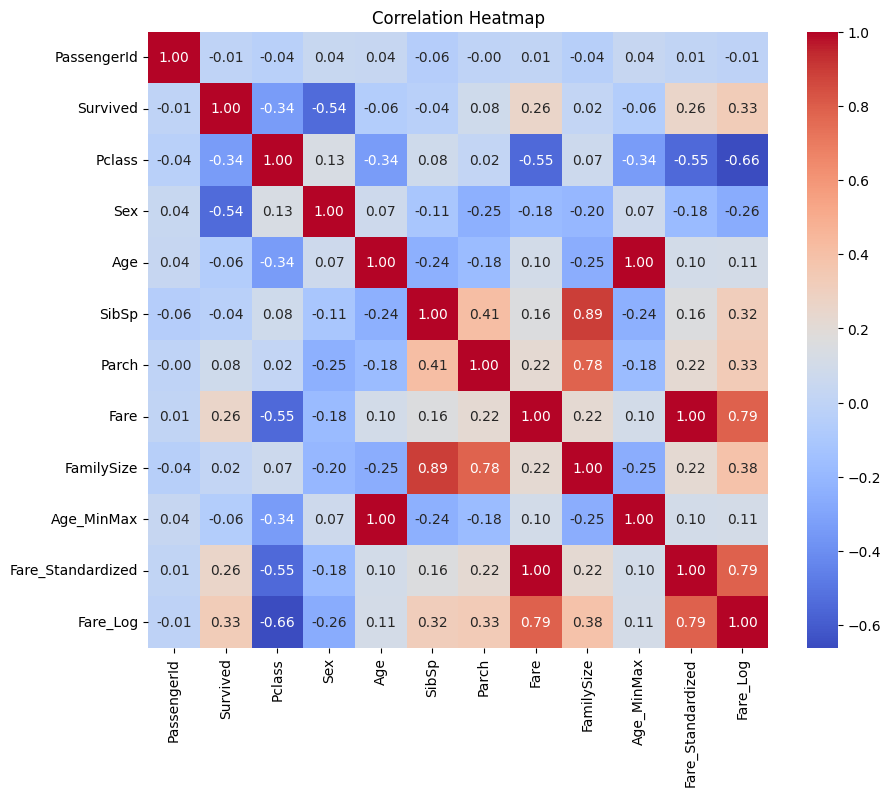

--- Top 3 Most Correlated Feature Pairs ---
Fare & Fare_Standardized: 1.0000
Age & Age_MinMax: 1.0000
SibSp & FamilySize: 0.8907


In [11]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

sol = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top3 = sol.abs().sort_values(ascending=False).head(3)

print("--- Top 3 Most Correlated Feature Pairs ---")
for (f1, f2), _ in top3.items():
    print(f"{f1} & {f2}: {corr.loc[f1, f2]:.4f}")

### Question 9: Data Visualization
- Create at least three different types of plots to reveal insights about the dataset.
- Explain your findings for each plot.

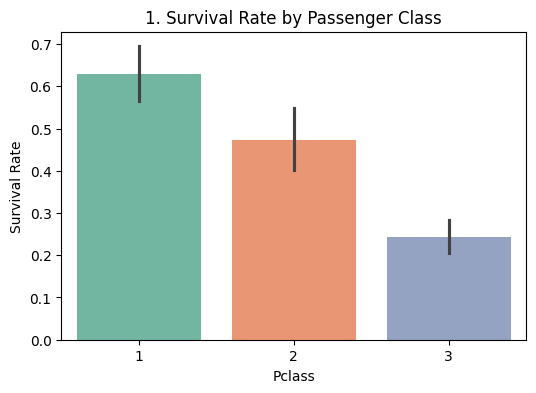

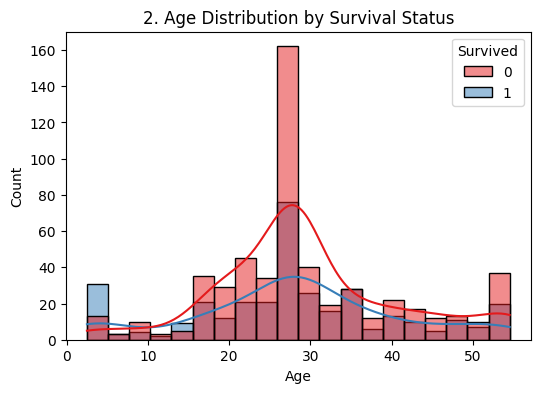

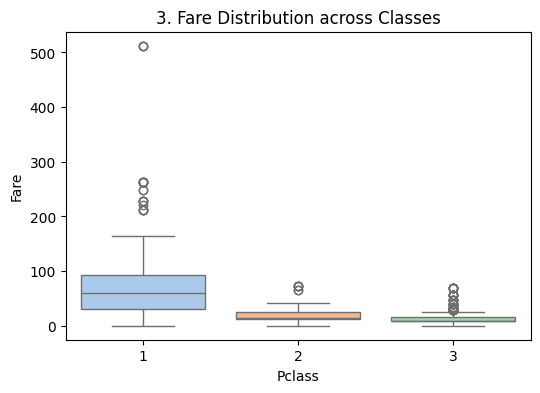

In [12]:

plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=df, palette='Set2', legend=False)
plt.title('1. Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette='Set1')
plt.title('2. Age Distribution by Survival Status')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x='Pclass', y='Fare', hue='Pclass', data=df, palette='pastel', legend=False)
plt.title('3. Fare Distribution across Classes')
plt.show()


### Question 10: Feature Selection
- Based on your analysis, select the top 5 features you believe are most important for predicting survival.
- Justify your choices.





In [13]:
# Sex
## Justification: As seen during data exploration, passenger gender is single-handedly the strongest predictor of survival on the Titanic. The "women and children first" policy resulted in a dramatic disparity, where female passengers had a survival rate near 74%, compared to under 20% for males.

#Pclass
## Justification: Socioeconomic status was a essential determinant of survival. The correlation heatmap and bar plots showed a direct linear decline in survival rates from 1st class (~63%) down to 3rd class (~24%), largely driven by cabin proximity to upper-deck lifeboats and priority boarding access.

#Fare_Log
## Justification: Ticket price acts as a high-resolution proxy for socioeconomic status and cabin position within a class. Using the log-transformed version removes the heavy right-skew and extreme outliers, providing ML models with a smooth, continuous indicator that correlates strongly with survival.

#Age
##Justification: The age distribution plots revealed a significant survival advantage for young children (ages 0–10) relative to working-age adults. Retaining age allows classification models to capture non-linear survival dynamics between children, adults, and elderly passengers.

#FamilySize
## Justification: Engineered as SibSP + Parch + 1, family size captures group dynamics during evacuation. Solo travelers had lower survival rates, moderate family sizes (2–4 members) saw improved coordination and survival, and very large families faced severe difficulties remaining together, making it far more informative than raw SibSp or Parch alone.